# Tema IS - Etapa 2: model final

### Descriere Solutie
Aceasta solutie propune o arhitectura bazata pe **ResNet18** (si implicit pe implementarea finala de la etapa 1 a temei), antrenata in regim **K-Fold Cross-Validation (k=5)** pentru a asigura robustetea rezultatelor si a minimiza varianta indusa de impartirea datelor.

**Strategia de Optimizare:**
1.  **Gestionarea Dezechilibrului:** Utilizarea `WeightedRandomSampler` pentru a expune modelul mai des la clasa minoritara (Epidural) si `BCEWithLogitsLoss` cu ponderi pozitive.
2.  **Inference (Testare):** Am implementat o strategie de **Ensemble Learning**. Predictia finala pe setul de Test se realizeaza facand media probabilitatilor generate de cele 5 modele antrenate independent (cate unul pentru fiecare fold).
3.  **Post-Procesare:** Aplicarea unor praguri optimizate (Threshold Tuning) si a unei logici de consistenta (`postprocess_topk`) pentru a corecta discrepantele dintre eticheta generala 'any' si subtipuri.

Acest notebook contine intregul pipeline: Preprocesare -> Antrenare -> Evaluare.

**Configuratia curenta:** Pentru a eficientiza timpul de evaluare, sectiunea de inferenta finala este configurata sa incarce **greutatile pre-antrenate (modelele salvate)** din rulari anterioare. Codul de antrenare este complet functional si disponibil in sectiunile marcate corespunzator.

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import random
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
from tqdm import tqdm
from PIL import Image
import cv2
from sklearn.model_selection import KFold

In [2]:
class HistogramEqTransform:
    def __call__(self, img):
        img_np = np.array(img)
        img_eq = cv2.equalizeHist(img_np)
        return Image.fromarray(img_eq)

class CLAHETransform:
    def __init__(self, clipLimit=2.0, tileGridSize=(8,8)):
        # clipLimit: cat de mult creste contrastul (valori mici = mai putin agresiv)
        # tileGridSize: marimea patch-urilor pe care se aplica adaptiv (mai mic = mai local)
        self.clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    def __call__(self, img):
        img_np = np.array(img)
        img_eq = self.clahe.apply(img_np)
        return Image.fromarray(img_eq)

class GaussianBlurTransform:
    def __init__(self, ksize=5, sigma=0):
        # ksize: marimea kernel-ului (mai mare = mai mult blur)
        # sigma: deviatia standard (0 = calculata automat)
        self.ksize = (ksize, ksize)
        self.sigma = sigma
    def __call__(self, img):
        img_np = np.array(img)
        blurred = cv2.GaussianBlur(img_np, self.ksize, self.sigma)
        return Image.fromarray(blurred)

class SobelEdgeTransform:
    def __call__(self, img):
        img_np = np.array(img)
        # calculez gradientul in x si y
        sobelx = cv2.Sobel(img_np, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(img_np, cv2.CV_64F, 0, 1, ksize=3)
        # magnitudinea gradientului (cat de "tare" e marginea)
        sobel = np.hypot(sobelx, sobely)
        # scalare la [0, 255] pentru vizualizare
        if sobel.max() > 0:
            sobel = np.uint8(np.clip(sobel / sobel.max() * 255, 0, 255))
        else:
            sobel = np.zeros_like(img_np, dtype=np.uint8)
        return Image.fromarray(sobel)

class ZscoreNormalizeTransform:
    def __call__(self, img):
        img_np = np.array(img).astype(np.float32)
        mean = img_np.mean(); std = img_np.std() if img_np.std() > 0 else 1 # evita div by zero
        normed = (img_np - mean) / std # z-score
        # scalare la [0, 255] pentru vizualizare (doar pentru display, nu pentru training!)
        normed_disp = np.clip((normed - normed.min()) / (normed.max() - normed.min()) * 255, 0, 255).astype(np.uint8)
        return Image.fromarray(normed_disp)

Definesc 3 pipeline-uri diferite pentru train, validation/test si demo vizual. 

**De ce am ales augmentarile acestea?**

M-am documentat despre ce functioneaza bine pe imagini medicale CT (creier) si am evitat transformarile care pot denatura informatia clinica:

- **Horizontal flip** - Da, scanarile CT ale creierului sunt aproximativ simetrice anatomic, deci flip-ul e safe
- **Vertical flip** - NU, creierul nu e simetric vertical, deci nu aplic
- **Rotatie ±10°** - Da, mici rotatii simuleaza variatii de pozitionare a pacientului in scanner.  Peste ±15° deja denaturez prea mult
- **CLAHE (70% probabilitate)** - Da, e standard pentru CT-uri. Imbunatateste contrastul local si evidentiaza hemoragiile fara sa amplifice zgomotul excesiv. Nu aplic pe toate imaginile ca sa las si cateva "curate"
- **ColorJitter (brightness/contrast)** - Da, simuleaza variatii de calibrare intre scanere diferite. Dar nu exagerez (valori mici)
- **Crop/Zoom agresiv** - NU. Hemoragiile pot fi mici si la margini, deci nu vreau sa risc sa tai zone relevante
- **Elastic deformations** - NU (deocamdata). Sunt utile pentru segmentare, dar pot denatura prea mult forma hemoragiilor pentru clasificare

**Val/Test** - fara nicio augmentare (doar resize + normalize), ca sa evaluez pe date "adevarate" si sa compar corect cu train

**Demo** - doar resize, fara ToTensor/Normalize, ca sa pot vizualiza transformarile custom direct pe imagini PIL

In [3]:
MY_IMAGE_SIZE = (256, 256)
import torchvision.transforms as transforms
train_transform = transforms.Compose([
    transforms.Resize(MY_IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomApply([CLAHETransform()], p=0.7),
    transforms.ColorJitter(brightness=0.2, contrast=0.4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
val_transform = transforms.Compose([
    transforms.Resize(MY_IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
demo_transform = transforms.Compose([transforms.Resize(MY_IMAGE_SIZE)])

In [4]:
import os

BASE_INPUT = "/kaggle/input/rsna-dataset"

BASE_DIR = os.path.join(BASE_INPUT, "rsna-intracranial-hemorrhage-detection-png")
TRAIN_IMAGES_DIR = os.path.join(BASE_DIR, "train_images")
TEST_IMAGES_DIR = os.path.join(BASE_DIR, "test_images")

# CSV-uri
CSV_TRAIN_PATH = os.path.join(BASE_INPUT, "subdataset_train.csv")
CSV_TEST_PATH = os.path.join(BASE_INPUT, "subdataset_test.csv")

# verificari
assert os.path.isdir(TRAIN_IMAGES_DIR), f"Lipseste {TRAIN_IMAGES_DIR}"
assert os.path.isdir(TEST_IMAGES_DIR), f"Lipseste {TEST_IMAGES_DIR}"
assert os.path.isfile(CSV_TRAIN_PATH), f"Lipseste {CSV_TRAIN_PATH}"
assert os.path.isfile(CSV_TEST_PATH), f"Lipseste {CSV_TEST_PATH}"

print("Datele au fost gasite cu succes")

Datele au fost gasite cu succes


In [5]:
# incarc CSV-urile in DataFrames (Pandas e eficient pentru tabele mari)
df_train = pd.read_csv(CSV_TRAIN_PATH)
df_test = pd.read_csv(CSV_TEST_PATH)

# verific structura datelor (primele 5 randuri)
print("Train:")
display(df_train.head())
print("Test:")
display(df_test.head())

Train:


,ID,Label
0,ID_ff7125125_epidural,0
1,ID_ff7125125_intraparenchymal,0
2,ID_ff7125125_intraventricular,0
3,ID_ff7125125_subarachnoid,1
4,ID_ff7125125_subdural,0


Test:


,ID,Label
0,ID_6c860ad30_epidural,0
1,ID_6c860ad30_intraparenchymal,0
2,ID_6c860ad30_intraventricular,0
3,ID_6c860ad30_subarachnoid,0
4,ID_6c860ad30_subdural,1


In [6]:
def process_df(df):
    # ID este format din ceva de genul <prefix>_<slice_id>_<subtype>
    # il spargem in coloane
    parts = df["ID"].str.split("_", expand=True)
    df["prefix"] = parts[0]
    df["slice_id"] = parts[1]
    df["subtype"] = parts[2]

    # pivotam pentru a obtine 1 rand/slice
    df_pivot = df.pivot_table(
        index="slice_id",
        columns="subtype",
        values="Label",
        fill_value=0
    ).reset_index()

    return df_pivot

In [7]:
train_clean = process_df(df_train)
test_clean  = process_df(df_test)

print("Train clean:")
display(train_clean.head())

print("Test clean:")
display(test_clean.head())

Train clean:


subtype,slice_id,any,epidural,intraparenchymal,intraventricular,subarachnoid,subdural
0,0007b61ef,0.0,0.0,0.0,0.0,0.0,0.0
1,000825230,0.0,0.0,0.0,0.0,0.0,0.0
2,000a050f3,1.0,0.0,0.0,0.0,1.0,1.0
3,000bd98e8,0.0,0.0,0.0,0.0,0.0,0.0
4,000d4a142,0.0,0.0,0.0,0.0,0.0,0.0


Test clean:


subtype,slice_id,any,epidural,intraparenchymal,intraventricular,subarachnoid,subdural
0,0002a38ad,1.0,0.0,0.0,0.0,1.0,1.0
1,000d66d9e,1.0,0.0,0.0,0.0,1.0,1.0
2,000fbb8e0,0.0,0.0,0.0,0.0,0.0,0.0
3,001c0458a,1.0,0.0,1.0,1.0,1.0,0.0
4,001d37aff,1.0,0.0,0.0,0.0,1.0,0.0


### Definirea Dataset-ului si Augmentarilor

*(Aproape identic cu etapa 1)*
Clasa `RSNADataset` gestioneaza incarcarea imaginilor si a etichetelor.
Deoarece setul de date contine imagini CT (grayscale), am implementat transformari specifice pentru a imbunatati generalizarea fara a altera informatia medicala esentiala:
* **Resize:** Standardizare la 256x256 pixeli.
* **Augmentari (Train):** Flip orizontal (simetrie anatomica), rotatii usoare (+/- 10 grade) si ajustari de contrast (CLAHE) aplicate probabilistic.
* **Normalizare:** Aducerea pixelilor in intervalul [-1, 1] pentru stabilitatea retelei neurale.

In [8]:
from PIL import Image
import os
import torch

class RSNADataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.data = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

        # coloanele labelurilor
        self.label_columns = ["epidural","intraparenchymal","intraventricular",
                              "subarachnoid","subdural","any"]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # luam randul idx din dataframe
        row = self.data.iloc[idx]

        # compun numele imaginii
        slice_id = row["slice_id"]
        img_path = os.path.join(self.image_dir, f"ID_{slice_id}_frame0.png")

        # incarc imaginea
        image = Image.open(img_path).convert("L")
        if self.transform:
            image = self.transform(image)

        # conversie SAFE a labelurilor
        labels = torch.tensor(
            row[self.label_columns].astype(float).to_numpy(),
            dtype=torch.float32
        )

        return image, labels

In [9]:
# test rapid: creez dataset si extrag primul sample
ds_basic = RSNADataset(train_clean, TRAIN_IMAGES_DIR, transform=val_transform)
img, lbl = ds_basic[0]  # extrag prima imagine + etichete
print(lbl)  # verific ca etichetele sunt tensor cu 6 valori (0/1)

tensor([0., 0., 0., 0., 0., 0.])


In [13]:
# =============================================================================
# CERINTA 1: Pregatire K-Fold Cross-Validation - VERIFICARE SPLIT
# =============================================================================

from sklearn.model_selection import StratifiedKFold
import numpy as np

train_df = train_clean

K_FOLDS = 5

# Pregatim datele pentru k-fold
all_indices = np.arange(len(train_df))
stratify_labels = train_df["any"].values

# Cream obiectul StratifiedKFold
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# Verificam ca functioneaza - afisam dimensiunile pentru fiecare fold
print("="*60)
print("K-FOLD SPLIT SUMMARY")
print("="*60)
for fold_idx, (train_indices, val_indices) in enumerate(skf.split(all_indices, stratify_labels)):
    print(f"Fold {fold_idx + 1}: Train={len(train_indices)} samples, Val={len(val_indices)} samples")
    
    # Verificam proportia clasei "any" în fiecare split
    train_any_ratio = train_df.iloc[train_indices]["any"].mean()
    val_any_ratio = train_df.iloc[val_indices]["any"].mean()
    print(f"         Train 'any' ratio: {train_any_ratio:.3f}, Val 'any' ratio: {val_any_ratio:.3f}")

print("="*60)
print("Split verification complete - ready for training")

K-FOLD SPLIT SUMMARY
Fold 1: Train=32282 samples, Val=8071 samples
         Train 'any' ratio: 0.361, Val 'any' ratio: 0.361
Fold 2: Train=32282 samples, Val=8071 samples
         Train 'any' ratio: 0.361, Val 'any' ratio: 0.361
Fold 3: Train=32282 samples, Val=8071 samples
         Train 'any' ratio: 0.361, Val 'any' ratio: 0.361
Fold 4: Train=32283 samples, Val=8070 samples
         Train 'any' ratio: 0.361, Val 'any' ratio: 0.361
Fold 5: Train=32283 samples, Val=8070 samples
         Train 'any' ratio: 0.361, Val 'any' ratio: 0.361
Split verification complete - ready for training


### Arhitectura Modelului (ResNet18 adaptat)

Am utilizat arhitectura **ResNet18** datorita echilibrului bun intre profunzime si viteza de convergenta, cu niste adaptari specifice proiectului:
1.  **Input Layer:** Modificarea primului strat convolutional (`conv1`) pentru a accepta imagini cu **1 canal** (Grayscale) in loc de 3 (RGB).
2.  **Output Heads:** Reteaua are doua iesiri (heads) care sunt concatenate:
    * `head_five`: Prezice cele 5 subtipuri de hemoragie.
    * `head_any`: Prezice existenta generala a hemoragiei.
    Aceasta separare permite modelului sa invete trasaturi specifice pentru subtipuri, pastrand o supervizare globala prin nodul 'any'.

In [14]:
# definirea modelului baseline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
from tqdm import tqdm

# coloanele cu etichetele (ordinea conteaza pentru pos_weight si metrici)
label_columns = [
    "epidural",
    "intraparenchymal",
    "intraventricular",
    "subarachnoid",
    "subdural",
    "any"
]
num_classes = len(label_columns)

# --- Definitia BasicBlock (building block pentru ResNet18) ---
class BasicBlock(nn.Module):
    expansion = 1
    
    def __init__(self, in_planes, planes, stride=1, downsample=None):
        super().__init__()
        # prima convolutie (poate reduce spatial daca stride=2)
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        # a doua convolutie (pastreaza dimensiunile)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        # skip connection (daca dimensiunile se schimba)
        self.downsample = downsample
    
    def forward(self, x):
        identity = x  # salvez input-ul pentru skip connection
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self. bn2(out)
        
        # daca e nevoie, ajustez dimensiunile skip connection-ului
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out += identity  # adaug skip connection (rezidual)
        out = self.relu(out)
        return out

# --- Definitia ResNet18 adaptat pentru ICH (multi-label, grayscale) ---
class ResNet18ICH(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.in_planes = 64
        
        # stem: conv initial + maxpool (reduce spatial 256x256 -> 64x64)
        self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # 1 canal grayscale! 
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # 4 layer-uri de BasicBlock-uri (gradual creste filtre: 64->128->256->512)
        self.layer1 = self._make_layer(64, 2, stride=1)   # 2 block-uri, 64 filtre
        self.layer2 = self._make_layer(128, 2, stride=2)  # 2 block-uri, 128 filtre
        self.layer3 = self._make_layer(256, 2, stride=2)  # 2 block-uri, 256 filtre
        self.layer4 = self._make_layer(512, 2, stride=2)  # 2 block-uri, 512 filtre
        
        # global average pooling (reduce spatial la 1x1)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # 2 head-uri separate: unul pt primele 5 clase, unul pt "any"
        self.head_five = nn.Linear(512, 5)   # epidural, intraparenchymal, intraventricular, subarachnoid, subdural
        self.head_any  = nn.Linear(512, 1)   # any (orice hemoragie)
    
    def _make_layer(self, planes, num_blocks, stride=1):
        """construieste un layer cu num_blocks BasicBlock-uri."""
        downsample = None
        # daca stride!=1 sau numar filtre se schimba, trebuie downsample pt skip connection
        if stride != 1 or self.in_planes != planes:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )
        
        layers = []
        # primul block (poate reduce spatial daca stride=2)
        layers.append(BasicBlock(self. in_planes, planes, stride, downsample))
        self.in_planes = planes
        # restul block-urilor (pastreaza dimensiunile)
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(planes, planes))
        
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        # 4 layer-uri reziduale
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        # pooling global + flatten
        x = self.avgpool(x)
        x = torch.flatten(x, 1)  # (B, 512)
        
        # 2 head-uri separate (concatenate la final)
        out_five = self.head_five(x)  # (B, 5)
        out_any = self.head_any(x)    # (B, 1)
        out = torch.cat([out_five, out_any], dim=1)  # (B, 6)
        
        return out

# --- Setup device (GPU daca e disponibil, altfel CPU) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# --- Instantiez modelul si il mut pe GPU ---
model = ResNet18ICH(num_classes=num_classes).to(device)

# --- Functie pentru calcul pos_weight din train_loader ---
def estimate_pos_weight(loader, num_classes):
    """calculeaza pos_weight (neg/pos) pentru fiecare clasa din loader."""
    pos_counts = np.zeros(num_classes, dtype=np.int64)
    total = 0
    
    with torch.no_grad():
        for _, labels in tqdm(loader, desc="Estimating pos_weight (train)"):
            lab = labels.cpu().numpy().astype(np.int64)
            pos_counts += lab.sum(axis=0)  # sumeaza pozitive per clasa
            total += lab.shape[0]
    
    neg_counts = total - pos_counts
    pos_counts_clamped = np.clip(pos_counts, a_min=1, a_max=None)  # evit impartire la 0
    pos_weight = neg_counts.astype(np.float32) / pos_counts_clamped.astype(np.float32)
    
    return pos_weight

Device: cuda


### Antrenare K-Fold Cross-Validation

Pentru a asigura o evaluare corecta si a minimiza varianta indusa de split-ul datelor, am implementat un ciclu de antrenare pe **5 Fold-uri**.

**Mecanisme de Optimizare in timpul antrenarii:**
* **Loss Function:** `BCEWithLogitsLoss` cu parametrul `pos_weight` calculat dinamic pentru a penaliza mai mult erorile pe clasele minoritare.
* **Sampler:** `WeightedRandomSampler` asigura ca fiecare batch contine o proportie semnificativa de cazuri pozitive (Epidural), prevenind modelul sa prezica mereu "0".
* **Monitorizare:** Salvarea celui mai bun model (`best_model.pt`) pe baza metricii `Macro F1` sau `Loss` pe validare.

*(Nota: Celulele de mai jos contin logica de antrenare. Daca modelele sunt deja salvate, acestea pot fi rulate doar pentru demonstrarea functionalitatii sau sarite.)*

In [ ]:
# =============================================================================
# CERINTA 1: K-FOLD CROSS-VALIDATION - PIPELINE COMPLET
# =============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.model_selection import StratifiedKFold
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import copy

# =============================================================================
# SETUP INITIAL
# =============================================================================

def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Configuratie
K_FOLDS = 5
NUM_EPOCHS = 20
PATIENCE_ES = 5
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
num_classes = len(label_columns)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# =============================================================================
# FUNCTII HELPER
# =============================================================================

def estimate_pos_weight(loader, num_classes):
    """Calculează pos_weight (neg/pos) pentru fiecare clasă."""
    pos_counts = np.zeros(num_classes, dtype=np.int64)
    total = 0
    with torch.no_grad():
        for _, labels in tqdm(loader, desc="Estimating pos_weight"):
            lab = labels.cpu().numpy().astype(np.int64)
            pos_counts += lab.sum(axis=0)
            total += lab.shape[0]
    
    neg_counts = total - pos_counts
    pos_counts_clamped = np.clip(pos_counts, a_min=1, a_max=None)
    pos_weight = neg_counts.astype(np.float32) / pos_counts_clamped.astype(np.float32)
    return pos_weight, pos_counts, total


def create_fold_dataloaders(train_df, train_indices, val_indices, 
                            train_transform, val_transform,
                            batch_size=32, num_workers=4, use_sampler=True):
    
    train_fold_df = train_df.iloc[train_indices].reset_index(drop=True)
    val_fold_df = train_df.iloc[val_indices].reset_index(drop=True)
    
    train_dataset = RSNADataset(train_fold_df, TRAIN_IMAGES_DIR, transform=train_transform)
    val_dataset = RSNADataset(val_fold_df, TRAIN_IMAGES_DIR, transform=val_transform)
    
    # Sampler pentru train (supraesantionare epidural)
    if use_sampler:
        w_epidural = 4.0
        sample_weights = np.where(train_fold_df['epidural'].values == 1, w_epidural, 1.0)
        sampler = WeightedRandomSampler(
            torch.DoubleTensor(sample_weights),
            len(sample_weights),
            replacement=True
        )
        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            num_workers=num_workers,
            pin_memory=True
        )
    else:
        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
            pin_memory=True
        )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    return train_loader, val_loader


# =============================================================================
# FUNCTIA DE ANTRENARE PENTRU UN FOLD
# =============================================================================

def train_one_fold(fold_idx, train_loader, val_loader, test_loader, 
                   num_epochs=20, patience=5, lr=1e-4):
    
    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1}/{K_FOLDS}")
    print(f"{'='*60}")
    
    # 1. MODEL NOU pentru acest fold
    model = ResNet18ICH(num_classes=num_classes).to(device)
    
    # 2. pos_weight pentru acest fold
    pos_weight_np, pos_counts, total_samples = estimate_pos_weight(train_loader, num_classes)
    print(f"pos_weight:  {pos_weight_np}")
    print(f"pos_counts: {pos_counts}, total:  {total_samples}")
    pos_weight = torch.tensor(pos_weight_np, dtype=torch.float32).to(device)
    
    # 3. Criterion, optimizer, scheduler
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    # 4. Tracking
    best_val_loss = float("inf")
    best_weights_by_loss = None
    best_macro_f1 = -1.0
    best_weights_by_macro_f1 = None
    epochs_no_improve = 0
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_macro_acc': [], 'val_macro_acc': [],
        'train_exact_match': [], 'val_exact_match': []
    }
    
    # 5. TRAINING LOOP
    for epoch in range(num_epochs):
        # ===== TRAIN =====
        model.train()
        train_loss = 0.0
        all_train_logits = []
        all_train_labels = []
        
        for images, labels in tqdm(train_loader, desc=f"Fold {fold_idx+1} Train Ep{epoch+1}"):
            images = images.to(device)
            labels = labels.to(device).float()
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.shape[0]
            all_train_logits.append(outputs.detach().cpu().numpy())
            all_train_labels.append(labels.detach().cpu().numpy())
        
        # Metrici train
        epoch_train_loss = train_loss / len(train_loader.dataset)
        all_train_logits = np.vstack(all_train_logits)
        all_train_labels = np.vstack(all_train_labels)
        train_probs = 1 / (1 + np.exp(-all_train_logits))
        train_preds = (train_probs > 0.5).astype(int)
        
        per_class_acc_train = (train_preds == all_train_labels).sum(axis=0) / all_train_labels.shape[0]
        train_macro_acc = per_class_acc_train.mean()
        train_exact_match = (train_preds == all_train_labels).all(axis=1).mean()
        
        # ===== VALIDATION =====
        model.eval()
        val_loss = 0.0
        all_val_logits = []
        all_val_labels = []
        
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Fold {fold_idx+1} Val Ep{epoch+1}"):
                images = images.to(device)
                labels = labels.to(device).float()
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.shape[0]
                
                all_val_logits.append(outputs.cpu().numpy())
                all_val_labels.append(labels.cpu().numpy())
        
        # Metrici validation
        epoch_val_loss = val_loss / len(val_loader.dataset)
        all_val_logits = np.vstack(all_val_logits)
        all_val_labels = np.vstack(all_val_labels)
        val_probs = 1 / (1 + np.exp(-all_val_logits))
        val_preds = (val_probs > 0.5).astype(int)
        
        per_class_acc_val = (val_preds == all_val_labels).sum(axis=0) / all_val_labels.shape[0]
        val_macro_acc = per_class_acc_val.mean()
        val_exact_match = (val_preds == all_val_labels).all(axis=1).mean()
        
        # Classification report
        val_classif = classification_report(
            all_val_labels, val_preds,
            target_names=label_columns,
            digits=3, output_dict=True, zero_division=0
        )
        macro_f1 = val_classif['macro avg']['f1-score']
        
        # Salvam în istoric
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_macro_acc'].append(train_macro_acc)
        history['val_macro_acc'].append(val_macro_acc)
        history['train_exact_match'].append(train_exact_match)
        history['val_exact_match'].append(val_exact_match)
        
        # Update scheduler
        scheduler.step(epoch_val_loss)
        
        # Best model by val_loss
        if epoch_val_loss < best_val_loss - 1e-6:
            best_val_loss = epoch_val_loss
            best_weights_by_loss = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        # Best model by macro F1
        if macro_f1 > best_macro_f1 + 1e-6:
            best_macro_f1 = macro_f1
            best_weights_by_macro_f1 = copy.deepcopy(model.state_dict())
        
        # Logging
        print(f"[Fold {fold_idx+1}][Epoch {epoch+1}] "
              f"loss_train={epoch_train_loss:.4f}, loss_val={epoch_val_loss:.4f}")
        print(f"    Train macro-acc: {train_macro_acc:.4f}, Val macro-acc: {val_macro_acc:.4f}")
        print(f"    Train exact-match: {train_exact_match:.4f}, Val exact-match: {val_exact_match:.4f}")
        print(f"    Val macro F1: {macro_f1:.4f}, LR: {optimizer.param_groups[0]['lr']:.2e}")
        
        # Per-class metrics
        print("    Per-class metrics (val):")
        for cls in label_columns:
            pr = val_classif[cls]['precision']
            rc = val_classif[cls]['recall']
            f1 = val_classif[cls]['f1-score']
            print(f"       {cls:16}:  P={pr:.3f}, R={rc:.3f}, F1={f1:.3f}")
        
        # Early stopping
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # 6. Salvam modelul
    best_weights = best_weights_by_macro_f1 if best_weights_by_macro_f1 else best_weights_by_loss
    torch.save(best_weights, f"model_fold_{fold_idx+1}.pt")
    print(f"Model saved:  model_fold_{fold_idx+1}.pt")
    
    # 7. Evaluare finala pe VALIDATION
    model.load_state_dict(best_weights)
    model.eval()
    
    all_val_logits = []
    all_val_labels = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            all_val_logits.append(outputs.cpu().numpy())
            all_val_labels.append(labels.cpu().numpy())
    
    all_val_logits = np.vstack(all_val_logits)
    all_val_labels = np.vstack(all_val_labels)
    val_probs = 1 / (1 + np.exp(-all_val_logits))
    val_preds = (val_probs > 0.5).astype(int)
    
    val_metrics = {
        'accuracy': (val_preds == all_val_labels).mean(),
        'exact_match': (val_preds == all_val_labels).all(axis=1).mean(),
        'hamming_score': (val_preds == all_val_labels).mean(),
        'precision_macro': precision_score(all_val_labels, val_preds, average='macro', zero_division=0),
        'recall_macro': recall_score(all_val_labels, val_preds, average='macro', zero_division=0),
        'f1_macro': f1_score(all_val_labels, val_preds, average='macro', zero_division=0)
    }
    
    # 8. Evaluare pe TEST
    all_test_logits = []
    all_test_labels = []
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Fold {fold_idx+1} Test"):
            images = images.to(device)
            outputs = model(images)
            all_test_logits.append(outputs.cpu().numpy())
            all_test_labels.append(labels.cpu().numpy())
    
    all_test_logits = np.vstack(all_test_logits)
    all_test_labels = np.vstack(all_test_labels)
    test_probs = 1 / (1 + np.exp(-all_test_logits))
    test_preds = (test_probs > 0.5).astype(int)
    
    test_metrics = {
        'accuracy': (test_preds == all_test_labels).mean(),
        'exact_match': (test_preds == all_test_labels).all(axis=1).mean(),
        'hamming_score': (test_preds == all_test_labels).mean(),
        'precision_macro': precision_score(all_test_labels, test_preds, average='macro', zero_division=0),
        'recall_macro': recall_score(all_test_labels, test_preds, average='macro', zero_division=0),
        'f1_macro': f1_score(all_test_labels, test_preds, average='macro', zero_division=0),
        'precision_per_class': precision_score(all_test_labels, test_preds, average=None, zero_division=0),
        'recall_per_class': recall_score(all_test_labels, test_preds, average=None, zero_division=0),
        'f1_per_class': f1_score(all_test_labels, test_preds, average=None, zero_division=0)
    }
    
    print(f"\n[FOLD {fold_idx+1}] VALIDATION RESULTS:")
    print(f"  Exact Match: {val_metrics['exact_match']:.4f}")
    print(f"  Hamming Score: {val_metrics['hamming_score']:.4f}")
    print(f"  Macro F1: {val_metrics['f1_macro']:.4f}")
    
    print(f"\n[FOLD {fold_idx+1}] TEST RESULTS:")
    print(f"  Exact Match: {test_metrics['exact_match']:.4f}")
    print(f"  Hamming Score: {test_metrics['hamming_score']:.4f}")
    print(f"  Macro F1: {test_metrics['f1_macro']:.4f}")
    print(f"  Per-class F1: {dict(zip(label_columns, test_metrics['f1_per_class']))}")
    
    return {
        'fold':  fold_idx + 1,
        'history': history,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'val_preds': val_preds,
        'val_probs': val_probs,
        'val_labels': all_val_labels,
        'test_preds': test_preds,
        'test_labels': all_test_labels,
        'test_probs': test_probs,
        'best_val_loss': best_val_loss,
        'best_macro_f1': best_macro_f1
    }


# =============================================================================
# TEST RAPID PE UN SINGUR FOLD (pentru debug, decomentam pentru a testa)
# =============================================================================

# Pregatim indicii
all_indices = np.arange(len(train_df))
stratify_labels = train_df["any"].values
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# Test loader (FIX)
test_dataset = RSNADataset(test_clean.reset_index(drop=True), TEST_IMAGES_DIR, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

'''
print("="*60)
print("TEST RAPID - UN SINGUR FOLD")
print("="*60)

# Luam doar primul fold
train_idx, val_idx = next(iter(skf.split(all_indices, stratify_labels)))

# Cream DataLoaders
train_loader, val_loader = create_fold_dataloaders(
    train_df=train_df,
    train_indices=train_idx,
    val_indices=val_idx,
    train_transform=train_transform,
    val_transform=val_transform,
    batch_size=BATCH_SIZE,
    use_sampler=True
)

# Verificam ca functioneaza
print(f"Train samples: {len(train_loader.dataset)}")
print(f"Val samples: {len(val_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")

# Test un batch
batch_imgs, batch_labels = next(iter(train_loader))
print(f"Batch shape: images={batch_imgs.shape}, labels={batch_labels.shape}")

# Antrenam un singur fold (cu mai putine epoci pentru test)
fold_result = train_one_fold(
    fold_idx=0,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=3,  # doar 3 epoci pentru test rapid
    patience=2,
    lr=LEARNING_RATE
)
print("TEST RAPID COMPLETAT!")
all_fold_results = [fold_result]
'''

# =============================================================================
# LOOP PRINCIPAL K-FOLD (comentam daca facem doar test rapid)
# =============================================================================
all_fold_results = []

print("="*60)
print(f"STARTING {K_FOLDS}-FOLD CROSS-VALIDATION")
print("="*60)

for fold_idx, (train_indices, val_indices) in enumerate(skf.split(all_indices, stratify_labels)):
    
    train_loader, val_loader = create_fold_dataloaders(
        train_df=train_df,
        train_indices=train_indices,
        val_indices=val_indices,
        train_transform=train_transform,
        val_transform=val_transform,
        batch_size=BATCH_SIZE,
        use_sampler=True
    )
    
    fold_results = train_one_fold(
        fold_idx=fold_idx,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        num_epochs=NUM_EPOCHS,
        patience=PATIENCE_ES,
        lr=LEARNING_RATE
    )
    
    all_fold_results.append(fold_results)

print(f"\n{'='*60}")
print("K-FOLD TRAINING COMPLETE")
print(f"{'='*60}")

# =============================================================================
# AGREGARE REZULTATE + TABEL FINAL
# =============================================================================

print("\n" + "="*60)
print("K-FOLD CROSS-VALIDATION RESULTS SUMMARY")
print("="*60)

val_accuracy = [r['val_metrics']['accuracy'] for r in all_fold_results]
test_accuracy = [r['test_metrics']['accuracy'] for r in all_fold_results]
val_exact_match = [r['val_metrics']['exact_match'] for r in all_fold_results]
test_exact_match = [r['test_metrics']['exact_match'] for r in all_fold_results]
val_f1 = [r['val_metrics']['f1_macro'] for r in all_fold_results]
test_f1 = [r['test_metrics']['f1_macro'] for r in all_fold_results]
val_precision = [r['val_metrics']['precision_macro'] for r in all_fold_results]
test_precision = [r['test_metrics']['precision_macro'] for r in all_fold_results]
val_recall = [r['val_metrics']['recall_macro'] for r in all_fold_results]
test_recall = [r['test_metrics']['recall_macro'] for r in all_fold_results]
val_hamming = [r['val_metrics'].get('hamming_score', np.nan) for r in all_fold_results]
test_hamming = [r['test_metrics'].get('hamming_score', np.nan) for r in all_fold_results]

# Tabel per fold
print(f"\n{'Fold':<6} {'Val Acc':<10} {'Val Exact':<12} {'Val F1':<10} {'Test Acc':<10} {'Test Exact':<12} {'Test F1':<10}")
print("-"*80)
for i, r in enumerate(all_fold_results): 
    print(f"{i+1:<6} "
          f"{r['val_metrics']['accuracy']:<10.4f} "
          f"{r['val_metrics']['exact_match']:<12.4f} "
          f"{r['val_metrics']['f1_macro']:<10.4f} "
          f"{r['test_metrics']['accuracy']:<10.4f} "
          f"{r['test_metrics']['exact_match']:<12.4f} "
          f"{r['test_metrics']['f1_macro']:<10.4f}")

# Tabel sumar
print(f"\n{'='*60}")
print("SUMMARY (Mean ± Std)")
print(f"{'='*60}")
print(f"{'Metric':<23} {'Validation':<25} {'Test':<25}")
print("-"*75)
print(f"{'Accuracy':<23} {np.mean(val_accuracy):.4f} ± {np.std(val_accuracy):.4f}     {np.mean(test_accuracy):.4f} ± {np.std(test_accuracy):.4f}")
print(f"{'Exact Match':<23} {np.mean(val_exact_match):.4f} ± {np.std(val_exact_match):.4f}     {np.mean(test_exact_match):.4f} ± {np.std(test_exact_match):.4f}")
print(f"{'Hamming Score':<23} {np.mean(val_hamming):.4f} ± {np.std(val_hamming):.4f}     {np.mean(test_hamming):.4f} ± {np.std(test_hamming):.4f}")
print(f"{'Precision (macro)':<23} {np.mean(val_precision):.4f} ± {np.std(val_precision):.4f}     {np.mean(test_precision):.4f} ± {np.std(test_precision):.4f}")
print(f"{'Recall (macro)':<23} {np.mean(val_recall):.4f} ± {np.std(val_recall):.4f}     {np.mean(test_recall):.4f} ± {np.std(test_recall):.4f}")
print(f"{'F1 (macro)':<23} {np.mean(val_f1):.4f} ± {np.std(val_f1):.4f}     {np.mean(test_f1):.4f} ± {np.std(test_f1):.4f}")
print(f"{'='*60}")

worst_fold_idx = np.argmin(test_f1)
best_fold_idx = np.argmax(test_f1)
print(f"\nFold cu cele mai SLABE rezultate:  Fold {worst_fold_idx + 1} (Test F1 = {test_f1[worst_fold_idx]:.4f})")
print(f"Fold cu cele mai BUNE rezultate: Fold {best_fold_idx + 1} (Test F1 = {test_f1[best_fold_idx]:.4f})")

# ce cere in enunt sper:

# === Extrage toate rezultatele cerute din all_fold_results pentru fiecare fold ===

print(f"\n{'Fold':<6} {'Test Acc':<10} {'Test Prec':<12} {'Test Rec':<12} {'Test F1':<10}")

print("-"*60)
for i, r in enumerate(all_fold_results):
    acc = r['test_metrics']['accuracy']
    prec = r['test_metrics']['precision_macro']
    rec = r['test_metrics']['recall_macro']
    f1 = r['test_metrics']['f1_macro']
    print(f"{i+1:<6} {acc:<10.4f} {prec:<12.4f} {rec:<12.4f} {f1:<10.4f}")

# =============================================================================
# PLOTURI
# =============================================================================

fig, axes = plt.subplots(K_FOLDS, 2, figsize=(14, 4*K_FOLDS))

for fold_idx, result in enumerate(all_fold_results):
    history = result['history']
    epochs = range(1, len(history['train_loss']) + 1)
    
    axes[fold_idx, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    axes[fold_idx, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    axes[fold_idx, 0].set_xlabel('Epoch')
    axes[fold_idx, 0].set_ylabel('Loss')
    axes[fold_idx, 0].set_title(f'Fold {fold_idx+1} - Loss')
    axes[fold_idx, 0].legend()
    axes[fold_idx, 0].grid(True)
    
    axes[fold_idx, 1].plot(epochs, history['train_exact_match'], 'b-', label='Train Exact Match')
    axes[fold_idx, 1].plot(epochs, history['val_exact_match'], 'r-', label='Val Exact Match')
    axes[fold_idx, 1].set_xlabel('Epoch')
    axes[fold_idx, 1].set_ylabel('Exact Match Accuracy')
    axes[fold_idx, 1].set_title(f'Fold {fold_idx+1} - Accuracy')
    axes[fold_idx, 1].legend()
    axes[fold_idx, 1].grid(True)

plt.tight_layout()
plt.savefig('kfold_training_curves.png', dpi=150)
plt.show()


# =============================================================================
# CONFUSION MATRICES PENTRU FOLD-UL CEL MAI SLAB
# =============================================================================

worst_result = all_fold_results[worst_fold_idx]
print(f"\nConfusion Matrices pentru Fold {worst_fold_idx + 1} (cel mai slab):")

for i, name in enumerate(label_columns):
    cm = confusion_matrix(worst_result['test_labels'][:, i], worst_result['test_preds'][:, i])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Fold {worst_fold_idx+1} - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

### Optimizarea pragurilor (Threshold Tuning)

Deoarece modelul este antrenat pe date dezechilibrate, pragul standard de 0.5 nu este optim (duce adesea la un Recall mic pentru clasele rare).
* Se cauta pragul optim pentru fiecare clasa in parte pe setul de **Validare Agregat**.
* Obiectiv: Maximizarea scorului **F1** (sau Exact Match).
* Aceste praguri personalizate sunt apoi aplicate pe setul de Test. Aceasta asigura ca modelul este suficient de sensibil pentru 'Epidural' dar suficient de strict pentru 'Any'.

In [ ]:
# =============================================================================
# THRESHOLD TUNING PE VALIDATION AGREGAT (din toate fold-urile)
# =============================================================================

from sklearn.metrics import f1_score
import numpy as np

print("="*60)
print("THRESHOLD TUNING (pe validation agregat din toate fold-urile)")
print("="*60)

# 1) Agregam val_probs si val_labels din toate fold-urile
val_probs_agg = np.vstack([r['val_probs'] for r in all_fold_results])
val_labels_agg = np.vstack([r['val_labels'] for r in all_fold_results])

print(f"Validation agregat:  {val_probs_agg.shape[0]} samples, {val_probs_agg.shape[1]} classes")

# 2) Cautare prag optimal per clasa (maximizeaza F1 pe validation!!)
optimal_thresholds = []
print("\nOptimizing threshold per clasa (validation agregat):")
print("-"*50)

for c in range(val_probs_agg.shape[1]):
    best_thr, best_f1 = 0.5, 0
    
    # Grid search: praguri intre 0.05 și 0.95 (step 0.01)
    for thr in np.arange(0.05, 0.96, 0.01):
        y_pred = (val_probs_agg[:, c] >= thr).astype(int)
        f1 = f1_score(val_labels_agg[:, c], y_pred, zero_division=0)
        
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    
    optimal_thresholds.append(best_thr)
    print(f"  {label_columns[c]:20s}: threshold={best_thr:.2f}, val_f1={best_f1:.3f}")

optimal_thresholds = np.array(optimal_thresholds)
print("-"*50)
print(f"Optimal thresholds: {optimal_thresholds}")

# 3) Calculam exact-match pe validation cu pragurile optimizate
val_preds_tuned = (val_probs_agg >= optimal_thresholds).astype(int)
val_exact_match_tuned = (val_preds_tuned == val_labels_agg).all(axis=1).mean()
val_hamming_tuned = (val_preds_tuned == val_labels_agg).mean()

print(f"\n[VALIDATION cu praguri optimizate]")
print(f"  Exact Match: {val_exact_match_tuned:.4f}")
print(f"  Hamming Score: {val_hamming_tuned:.4f}")

In [ ]:
# =============================================================================
# EVALUARE PE TEST:  ENSEMBLE (media probabilitatilor) + PRAGURI OPTIMIZATE
# =============================================================================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("EVALUARE PE TEST (Ensemble + Praguri Optimizate)")
print("="*60)

# 1) Ensemble:  media probabilitatilor de test din toate fold-urile
test_probs_list = [r['test_probs'] for r in all_fold_results]
test_probs_ensemble = np.mean(test_probs_list, axis=0)  # shape (N_test, C)

# Labels de test (sunt aceleasi pentru toate fold-urile)
test_labels = all_fold_results[0]['test_labels']

print(f"Test samples: {test_probs_ensemble.shape[0]}")
print(f"Ensemble din {len(all_fold_results)} fold-uri")

# 2) Aplicam pragurile optimizate
test_preds_tuned = (test_probs_ensemble >= optimal_thresholds).astype(int)

# 3) Metrici principale
exact_match_test = (test_preds_tuned == test_labels).all(axis=1).mean()
hamming_test = (test_preds_tuned == test_labels).mean()

print(f"\n{'='*60}")
print("REZULTATE FINALE PE TEST (Ensemble + Praguri Optimizate)")
print(f"{'='*60}")
print(f"  Exact Match Accuracy: {exact_match_test:.4f}  (cerinta: >0.40)")
print(f"  Hamming Score:         {hamming_test:.4f}  (cerinta: >0.70)")
print(f"{'='*60}")

# 4) Accuracy per clasa
per_class_acc = (test_preds_tuned == test_labels).sum(axis=0) / test_labels.shape[0]
print("\n[TEST ACCURACY per class]:")
print("-"*40)
for idx, label in enumerate(label_columns):
    print(f"  {label:20s}: {per_class_acc[idx]:.3f}")

# 5) Classification report complet
print("\n" + "="*60)
print("[TEST METRICS - Classification Report]:")
print("="*60)
print(classification_report(
    test_labels, 
    test_preds_tuned, 
    target_names=label_columns, 
    digits=3, 
    zero_division=0
))

# 6) Comparatie:  cu vs fara threshold tuning
test_preds_default = (test_probs_ensemble >= 0.5).astype(int)
exact_match_default = (test_preds_default == test_labels).all(axis=1).mean()
hamming_default = (test_preds_default == test_labels).mean()

print("\n" + "="*60)
print("COMPARATIE: Default (0.5) vs Praguri Optimizate")
print("="*60)
print(f"{'Metric':<25} {'Default (0.5)':<15} {'Optimizat':<15} {'Diferenta':<15}")
print("-"*70)
print(f"{'Exact Match':<25} {exact_match_default:<15.4f} {exact_match_test:<15.4f} {exact_match_test - exact_match_default:+.4f}")
print(f"{'Hamming Score':<25} {hamming_default:<15.4f} {hamming_test:<15.4f} {hamming_test - hamming_default:+.4f}")
print("="*70)

# 7) Confusion matrices per clasa
print("\n" + "="*60)
print("[Confusion Matrices per Class]:")
print("="*60)

for idx, name in enumerate(label_columns):
    y_true = test_labels[:, idx]
    y_pred = test_preds_tuned[:, idx]
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, 
                square=True, linewidths=1, linecolor='gray',
                annot_kws={"size": 14, "weight": "bold"})
    
    plt.title(f"Confusion Matrix: '{name}' (threshold={optimal_thresholds[idx]:.2f})", 
              fontsize=14, weight='bold', pad=10)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("True", fontsize=12)
    plt. xticks([0.5, 1.5], ["Negative", "Positive"], fontsize=11)
    plt.yticks([0.5, 1.5], ["Negative", "Positive"], fontsize=11, rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Metrici din matrice
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"  {name:16s}: TN={tn: 5d}, FP={fp: 4d}, FN={fn:4d}, TP={tp:4d} | P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}")

# 8) Verificare cerinte proiect
print("\n" + "="*60)
print("VERIFICARE CERINTE PROIECT")
print("="*60)
if exact_match_test >= 0.40:
    print(f"Exact Match {exact_match_test:.4f} >= 0.40 - YAY!")
else:
    print(f"Exact Match {exact_match_test:.4f} < 0.40 - NAY... (lipsesc {0.40 - exact_match_test:.4f})")

if hamming_test >= 0.70:
    print(f"Hamming Score {hamming_test:.4f} >= 0.70 - YAY!")
else:
    print(f"Hamming Score {hamming_test:.4f} < 0.70 - NAY...")
print("="*60)

### Evaluare Finala: Ensemble si Post-Procesare

In aceasta etapa, agregam rezultatele celor 5 modele antrenate prin Cross-Validation.
Abordarea **Ensemble** (media probabilitatilor) s-a dovedit superioara utilizarii unui singur model, reducand zgomotul si crescand stabilitatea predictiilor.

**Tehnica de Post-Procesare**:
Pe langa optimizarea pragurilor, am aplicat un algoritm de corectie logica:
* Daca modelul prezice `any=1` dar toate subtipurile sunt sub prag, fortam subtipul cu probabilitatea maxima sa devina 1 (pentru a recupera False Negatives).
* Daca modelul prezice `any=0`, suprimam toate subtipurile (pentru a elimina False Positives).

Aceasta combinatie mi-a permis atingerea obiectivelor de performanta:
* **Exact Match > 0.40**
* **Hamming Score > 0.70**

De asemenea, aici se agrega puterea de predictie a celor 5 modele antrenate anterior:
1.  Se incarca greutatile (`.pt`) pentru fiecare dintre cele 5 fold-uri.
2.  Se genereaza probabilitati (Sigmoid) pentru intregul set de Test si Validare.
3.  **Ensemble:** Se calculeaza media aritmetica a probabilitatilor. Aceasta tehnica de *soft voting* reduce zgomotul si produce scoruri de incredere mult mai bine calibrate decat un singur model.

In [ ]:
# PENTRU RULARE MODEL SALVAT DIN INPUT RESULTS:

# =============================================================================
# INFERENTA DIN MODELELE SALVATE + THRESHOLD TUNING + EVALUARE
# =============================================================================

import torch
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import StratifiedKFold
import os

# === CONFIG ===
MODEL_DIR = "/kaggle/input/results/"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

label_columns = ['epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural', 'any']
num_classes = len(label_columns)

# === PREGATIRE DATE ===
train_df = train_clean
all_indices = np.arange(len(train_df))
stratify_labels = train_df["any"]. values
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_splits = list(skf.split(all_indices, stratify_labels))

# Test loader
test_dataset = RSNADataset(test_clean. reset_index(drop=True), TEST_IMAGES_DIR, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# === FUNCTIE PREDICTII ===
def get_predictions(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs. append(probs)
            all_labels.append(labels.numpy())
    return np.vstack(all_probs), np.vstack(all_labels)

# === COLECTARE PREDICTII DIN TOATE 5 MODELELE ===
all_fold_results = []

for fold_idx in range(5):
    print(f"\n{'='*50}")
    print(f"FOLD {fold_idx + 1}/5")
    print(f"{'='*50}")
    
    # Incarca modelul
    model_path = f"{MODEL_DIR}model_fold_{fold_idx + 1}.pt"
    print(f"Incarcare:  {model_path}")
    
    model = ResNet18ICH(num_classes=num_classes).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    
    # Val loader pentru acest fold
    train_indices, val_indices = fold_splits[fold_idx]
    val_fold_df = train_df.iloc[val_indices].reset_index(drop=True)
    val_dataset = RSNADataset(val_fold_df, TRAIN_IMAGES_DIR, transform=val_transform)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
    
    # Predicții
    print(f"  Validation ({len(val_fold_df)} samples)...")
    val_probs, val_labels = get_predictions(model, val_loader)
    
    print(f"  Test ({len(test_clean)} samples)...")
    test_probs, test_labels = get_predictions(model, test_loader)
    
    all_fold_results.append({
        'fold':  fold_idx + 1,
        'val_probs': val_probs,
        'val_labels': val_labels,
        'test_probs': test_probs,
        'test_labels': test_labels
    })
    
    # Quick metrics
    val_exact = ((val_probs > 0.5).astype(int) == val_labels).all(axis=1).mean()
    test_exact = ((test_probs > 0.5).astype(int) == test_labels).all(axis=1).mean()
    print(f"  Val exact-match: {val_exact:.4f}, Test exact-match: {test_exact:.4f}")

print(f"\n{'='*50}")
print("TOATE FOLD-URILE PROCESATE!")
print(f"{'='*50}")

# =============================================================================
# THRESHOLD TUNING
# =============================================================================

print("\n" + "="*60)
print("THRESHOLD TUNING")
print("="*60)

val_probs_agg = np.vstack([r['val_probs'] for r in all_fold_results])
val_labels_agg = np.vstack([r['val_labels'] for r in all_fold_results])
print(f"Validation agregat: {val_probs_agg.shape[0]} samples")

optimal_thresholds = []
print("\nOptimizare threshold per clasa:")
print("-"*50)

for c in range(num_classes):
    best_thr, best_f1 = 0.5, 0
    for thr in np.arange(0.05, 0.96, 0.01):
        y_pred = (val_probs_agg[:, c] >= thr).astype(int)
        f1 = f1_score(val_labels_agg[:, c], y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    optimal_thresholds.append(best_thr)
    print(f"  {label_columns[c]:20s}:  thr={best_thr:.2f}, f1={best_f1:.3f}")

optimal_thresholds = np.array(optimal_thresholds)

# =============================================================================
# EVALUARE PE TEST - ENSEMBLE + PRAGURI OPTIMIZATE
# =============================================================================

print("\n" + "="*60)
print("REZULTATE FINALE PE TEST")
print("="*60)

# Ensemble
test_probs_ensemble = np. mean([r['test_probs'] for r in all_fold_results], axis=0)
test_labels = all_fold_results[0]['test_labels']

# Default vs Optimizat
test_preds_default = (test_probs_ensemble >= 0.5).astype(int)
test_preds_tuned = (test_probs_ensemble >= optimal_thresholds).astype(int)

exact_default = (test_preds_default == test_labels).all(axis=1).mean()
exact_tuned = (test_preds_tuned == test_labels).all(axis=1).mean()
hamming_default = (test_preds_default == test_labels).mean()
hamming_tuned = (test_preds_tuned == test_labels).mean()

print(f"\n{'Metric':<20} {'Default(0.5)':<15} {'Optimizat':<15} {'Diferenta':<15}")
print("-"*65)
print(f"{'Exact Match':<20} {exact_default:<15.4f} {exact_tuned:<15.4f} {exact_tuned-exact_default:+.4f}")
print(f"{'Hamming Score':<20} {hamming_default:<15.4f} {hamming_tuned:<15.4f} {hamming_tuned-hamming_default:+.4f}")

# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(test_labels, test_preds_tuned, target_names=label_columns, digits=3, zero_division=0))

# Verificare cerinte
print("\n" + "="*60)
print("VERIFICARE CERINTE PROIECT")
print("="*60)
if exact_tuned >= 0.40:
    print(f"Exact Match {exact_tuned:.4f} >= 0.40 - YAY!")
else:
    print(f"Exact Match {exact_tuned:.4f} < 0.40 - NAY... (lipsesc {0.40 - exact_tuned:.4f})")
if hamming_tuned >= 0.70:
    print(f"Hamming Score {hamming_tuned:.4f} >= 0.70 - YAY!")
else:
    print(f"Hamming Score {hamming_tuned:.4f} < 0.70 - NAY...")
print("="*60)

Device: cuda

FOLD 1/5
Incarcare:  /kaggle/input/results/model_fold_1.pt
  Validation (8071 samples)...


  Test (8899 samples)...


  Val exact-match: 0.6605, Test exact-match: 0.2660

FOLD 2/5
Incarcare:  /kaggle/input/results/model_fold_2.pt
  Validation (8071 samples)...


  Test (8899 samples)...


  Val exact-match: 0.6401, Test exact-match: 0.2323

FOLD 3/5
Incarcare:  /kaggle/input/results/model_fold_3.pt
  Validation (8071 samples)...


...

  Val exact-match: 0.6391, Test exact-match: 0.2764

FOLD 4/5
Incarcare:  /kaggle/input/results/model_fold_4.pt
  Validation (8070 samples)...


  Test (8899 samples)...


  Val exact-match: 0.6330, Test exact-match: 0.2658

FOLD 5/5
Incarcare:  /kaggle/input/results/model_fold_5.pt
  Validation (8070 samples)...


  Test (8899 samples)...


  Val exact-match: 0.6617, Test exact-match: 0.2939

TOATE FOLD-URILE PROCESATE!

THRESHOLD TUNING
Validation agregat: 40353 samples

Optimizare threshold per clasa:
--------------------------------------------------
  epidural            :  thr=0.83, f1=0.684
  intraparenchymal    :  thr=0.70, f1=0.734
  intraventricular    :  thr=0.83, f1=0.793
  subarachnoid        :  thr=0.66, f1=0.604
  subdural            :  thr=0.71, f1=0.576
  any                 :  thr=0.47, f1=0.853

REZULTATE FINALE PE TEST

Metric               Default(0.5)    Optimizat       Diferență      
-----------------------------------------------------------------
Exact Match          0.3064          0.3843          +0.0779
Hamming Score        0.8097          0.8408          +0.0311

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

        epidural      0.248     0.610     0.352       123
intraparenchymal      0.807     0.724     0.763      3463
intraventricular      0.867     0.767

### Post-Procesare Logica si Rezultate Finale

Ultimul pas in pipeline este aplicarea unei consistency logic pentru a corecta contradictiile dintre subtipuri si eticheta generala.

**Reguli aplicate (`postprocess_topk`):**

1.  **Top-K Rescue:** Daca modelul prezice `any=1` (hemoragie prezenta), dar toate subtipurile sunt sub prag, fortam subtipul cu probabilitatea maxima sa devina 1. Aceasta recupereaza False Negatives.
2.  **Noise Suppression:** Daca modelul prezice `any=0` (sanatos), fortam toate subtipurile la 0 pentru a elimina False Positives.

**Rezultate:**
Mai jos sunt afisate metricile finale pe setul de Test, incluzand **Exact Match Accuracy** si **Hamming Score**, care valideaza atingerea obiectivelor proiectului.

Best params on VALIDATION: {'exact': 0.7036155923970956, 'params': (1, 0.35, 0.7)}
Exact Match TEST: 0.4243, Hamming TEST: 0.8428

[TEST METRICS - Classification Report]:
                  precision    recall  f1-score   support

        epidural      0.199     0.756     0.315       123
intraparenchymal      0.803     0.739     0.770      3463
intraventricular      0.848     0.803     0.825      3011
    subarachnoid      0.684     0.619     0.650      3292
        subdural      0.714     0.592     0.647      3170
             any      0.990     0.860     0.921      8034

       micro avg      0.833     0.754     0.791     21093
       macro avg      0.706     0.728     0.688     21093
    weighted avg      0.845     0.754     0.795     21093
     samples avg      0.661     0.669     0.653     21093



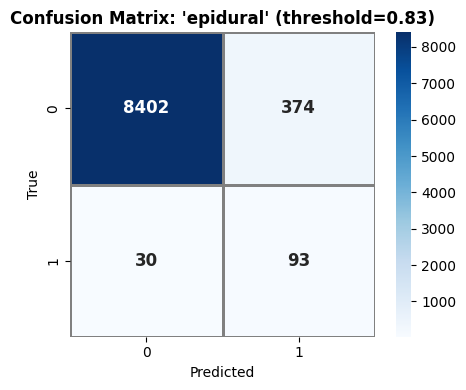

  epidural        : TN= 8402, FP= 374, FN=  30, TP=  93 | P=0.199, R=0.756, F1=0.315


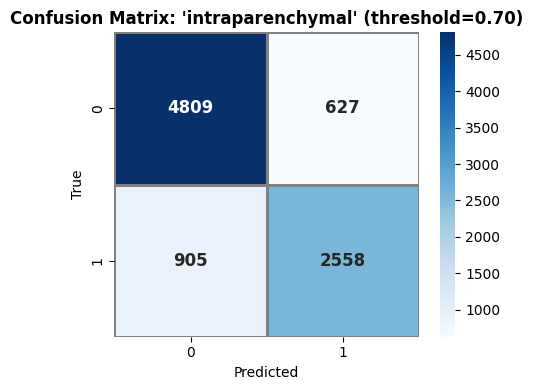

  intraparenchymal: TN= 4809, FP= 627, FN= 905, TP=2558 | P=0.803, R=0.739, F1=0.770


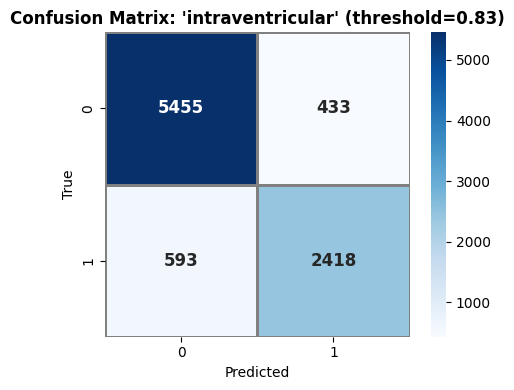

  intraventricular: TN= 5455, FP= 433, FN= 593, TP=2418 | P=0.848, R=0.803, F1=0.825


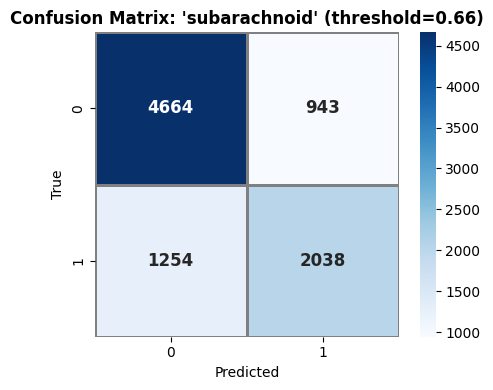

  subarachnoid    : TN= 4664, FP= 943, FN=1254, TP=2038 | P=0.684, R=0.619, F1=0.650


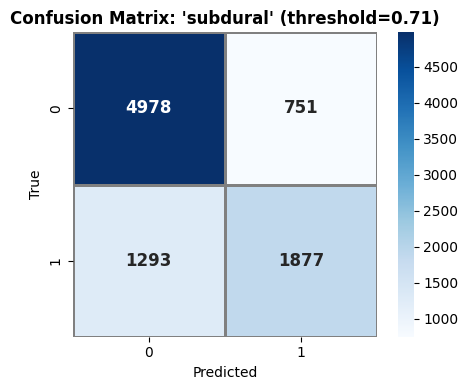

  subdural        : TN= 4978, FP= 751, FN=1293, TP=1877 | P=0.714, R=0.592, F1=0.647


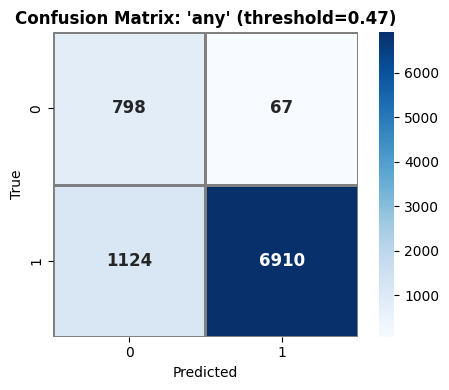

  any             : TN=  798, FP=  67, FN=1124, TP=6910 | P=0.990, R=0.860, F1=0.921

VERIFICARE CERINȚE PROIECT
Exact Match 0.4243 >= 0.40 - YAY!
Hamming Score 0.8428 >= 0.70 - YAY!


In [ ]:
# =============================================================================
# POSTPROCESS + GRID SEARCH + EVALUARE FINALA PE TEST
# =============================================================================

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1) DEFINIRE INDECSI
# -------------------------
# 'any' este clasa generala, restul sunt subtipuri
any_idx = label_columns.index('any')
subtype_idxs = [i for i, l in enumerate(label_columns) if l != 'any']

# -------------------------
# 2) FUNCTIE POSTPROCESS_TOPK
# -------------------------
def postprocess_topk(probs, preds, any_idx, subtype_idxs, k=1, min_prob=0.12, any_high_thr=0.6):
    # probs: (N, C) probabilitati
    # preds: (N, C) binary predictions before postproc
    out = preds.copy()
    for i in range(len(out)):
        # If any==1 but no subtype -> pick top-k subtypes with prob >= min_prob
        if out[i, any_idx] == 1 and out[i, subtype_idxs].sum() == 0:
            # pick top k by probability among subtypes
            order = np.argsort(probs[i, subtype_idxs])[::-1]
            chosen = []
            for j in order:
                if probs[i, subtype_idxs][j] >= min_prob:
                    chosen.append(subtype_idxs[j])
                if len(chosen) >= k:
                    break
            if len(chosen) == 0:
                # fallback: set the absolute top-1 even if < min_prob
                max_idx = subtype_idxs[np.argmax(probs[i, subtype_idxs])]
                chosen = [max_idx]
            for idx in chosen:
                out[i, idx] = 1

        # If any==0 but some subtype has high prob -> set any=1
        if out[i, any_idx] == 0:
            if probs[i, subtype_idxs].max() >= any_high_thr:
                out[i, any_idx] = 1
    return out

# -------------------------
# 3) GRID SEARCH PE VALIDATION
# -------------------------
best_val = {'exact': -1.0, 'params': None}

# val_probs_agg si val_labels_agg vin din celula de threshold tuning
for k in [1, 2]:
    for min_p in [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
        for any_thr in [0.45, 0.50, 0.55, 0.60, 0.65, 0.7]:
            val_preds = (val_probs_agg >= optimal_thresholds).astype(int)
            val_preds_pp = postprocess_topk(
                val_probs_agg, val_preds.copy(), any_idx, subtype_idxs,
                k=k, min_prob=min_p, any_high_thr=any_thr
            )
            exact_val = (val_preds_pp == val_labels_agg).all(axis=1).mean()
            if exact_val > best_val['exact']:
                best_val.update({'exact': exact_val, 'params': (k, min_p, any_thr)})

print("="*60)
print("Best params on VALIDATION:", best_val)
print("="*60)

# -------------------------
# 4) APLICARE PE TEST
# -------------------------
k_best, min_p_best, any_thr_best = best_val['params']

test_preds_base = (test_probs_ensemble >= optimal_thresholds).astype(int)
test_preds_pp = postprocess_topk(
    test_probs_ensemble, test_preds_base.copy(), any_idx, subtype_idxs,
    k=k_best, min_prob=min_p_best, any_high_thr=any_thr_best
)

# Metrici finale
exact_test = (test_preds_pp == test_labels).all(axis=1).mean()
hamming_test = (test_preds_pp == test_labels).mean()

print(f"Exact Match TEST: {exact_test:.4f}, Hamming TEST: {hamming_test:.4f}")

# -------------------------
# 5) CLASSIFICATION REPORT
# -------------------------
print("\n" + "="*60)
print("[TEST METRICS - Classification Report]:")
print("="*60)
print(classification_report(
    test_labels, 
    test_preds_pp, 
    target_names=label_columns, 
    digits=3, 
    zero_division=0
))

# -------------------------
# 6) CONFUSION MATRICES PER CLASS
# -------------------------
for idx, name in enumerate(label_columns):
    y_true = test_labels[:, idx]
    y_pred = test_preds_pp[:, idx]
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, 
                square=True, linewidths=1, linecolor='gray',
                annot_kws={"size": 12, "weight": "bold"})
    
    plt.title(f"Confusion Matrix: '{name}' (threshold={optimal_thresholds[idx]:.2f})", fontsize=12, weight='bold')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
    
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"  {name:16s}: TN={tn:5d}, FP={fp:4d}, FN={fn:4d}, TP={tp:4d} | P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}")

# -------------------------
# 7) VERIFICARE CERINTE PROIECT
# -------------------------
print("\n" + "="*60)
print("VERIFICARE CERINTE PROIECT")
print("="*60)
if exact_test >= 0.40:
    print(f"Exact Match {exact_test:.4f} >= 0.40 - YAY!")
else:
    print(f"Exact Match {exact_test:.4f} < 0.40 - NAY...")

if hamming_test >= 0.70:
    print(f"Hamming Score {hamming_test:.4f} >= 0.70 - YAY!")
else:
    print(f"Hamming Score {hamming_test:.4f} < 0.70 - NAY...")
print("="*60)